# Two-stage SHGD screening in maize: binomial simulation and HMF BLUES — reproduction

**Paper:** M. F. Fakude, T. L. Foster, Y.-R. Chen, A. Murithi, S. I. Aboobucker, U. K. Frei, P. M. Dixon, T. Lübberstedt (2026),
*"A two-stage screening approach integrated with GWAS for rare phenotypes such as spontaneous haploid genome doubling in maize"*,
Frontiers in Plant Science 17:1837152, DOI [10.3389/fpls.2026.1837152](https://doi.org/10.3389/fpls.2026.1837152).

**Author code:** [`Mercy-99/shgd-two-stage-screening`](https://github.com/Mercy-99/shgd-two-stage-screening) pinned at commit `b9076b006a694c1f5002b18c8079b46e6ad86fda`.

## Scope and execution status

This notebook reproduces the paper's **statistical screening-design analysis** (Results, "Optimizing HMF thresholds and testing scenarios via statistical simulations"; Materials and methods, "Simulation for SHGD screening") and the paper's **genotype-BLUE computation** for haploid male fertility (HMF), by running the authors' own R code and deposited phenotype data:

1. The authors' `threshold()` binomial screening function, run **verbatim** for 25/50/75 haploid plants per genotype across HMF thresholds, reproducing true discovery rate (TDR), detection probability, and false positive/negative rates that support the 25% HMF threshold with 50 plants.
2. Recomputation of genotype BLUES from the deposited HMF phenotype workbook, following the authors' `BLUES for GWAS` script (binomial GLM + `emmeans` + inverse-logit).

**Not reproduced here:** the field experiments, the GWAS (requires the Ames-panel GBS genotype subset for the 295 lines, which is not in the author repository and must be obtained from MaizeGDB/GRIN), and candidate-gene mapping.

- **Execution status:** all cells below were executed top-to-bottom on a fresh Google Colab **CPU** runtime; results shown are from that run (see the validation record at the end).
- **Runtime:** CPU only (statistics on a ≤ 10⁵-point grid; no GPU or deep learning involved).

日本語: このノートブックは、トウモロコシの自発的倍数化（SHGD）スクリーニング論文のうち、二段階スクリーニング設計を決めた**二項分布シミュレーション**と、HMF表現型データからの**遺伝子型BLUE計算**を、著者自身のRコードとデータで再現します。GWASや圃場試験は対象外です。実行はCPUのみで可能です。


## Runtime selection and how to run

**Select Runtime → Change runtime type → CPU** (default). A GPU is not needed: the analysis is exact binomial-tail probability computation plus a small GLM, all in R via `Rscript`.

Then **Runtime → Run all**. Expected duration: a few minutes (including `emmeans` install and the ~46 KB data download).

日本語: ランタイムはCPUを選択してください（GPU不要）。「ランタイム → すべてのセルを実行」で数分で完了します。

### Code cell: check the Python and R environments

This cell verifies that the Colab runtime provides the two interpreters this notebook needs: Python 3 (orchestration, plots, data export) and R via `/usr/bin/Rscript` (the authors' analysis language). The authors' script header states "screening computations for Mercy Fakude"; the simulation was "conducted in R" (paper, Materials and methods). Expect R ≥ 4.x on current Colab images.

日本語: Python 3 と R (`/usr/bin/Rscript`) の両方が使えることを確認します。著者の解析はRで実装されているためです。

In [ ]:
import subprocess, sys, importlib
print('Python:', sys.version)
for mod in ['openpyxl', 'matplotlib']:
    m = importlib.import_module(mod)
    print(f'{mod}:', m.__version__)
p = subprocess.run(['/usr/bin/Rscript', '--version'], capture_output=True, text=True)
p.check_returncode()
print(p.stdout.strip())

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]


openpyxl: 3.1.5
matplotlib: 3.10.0
Rscript (R) version 4.6.1 (2026-06-24)


## Minimal input acquisition (Colab only)

All inputs are fetched from the author repository pinned at commit `b9076b006a694c1f5002b18c8079b46e6ad86fda`:

| File | Role |
| --- | --- |
| `Data_Haploid male fertility .xlsx` (45,569 B) | deposited HMF phenotype data (paper, Data availability statement) |
| `Simulation code_two-stage screening.txt` | authors' R simulation code (paper, "Simulation for SHGD screening") |
| `BLUES for GWAS_code_Haploid male fertility.txt` | authors' R BLUES code (paper, "Statistical analysis of phenotypic data") |

The expected SHA-256 of the workbook was verified in a prior run of this notebook; it is re-checked here after download (`73fef6a2…25029`). Dataset bytes are downloaded and processed only inside this Colab runtime.

日本語: 著者リポジトリの固定コミットから、HMF表現型データ(xlsx)とRコード2本をColab内にダウンロードし、SHA-256で検証します。データはColab内でのみ扱います。

### Code cell: download and verify the pinned inputs

Downloads the three pinned files from `raw.githubusercontent.com` at the exact commit, checks HTTP status, the ZIP magic bytes of the workbook, its byte length, and its SHA-256 against the recorded value, and fails loudly on any mismatch. Expect: 45,569 bytes, SHA-256 `73fef6a2a41073ad6af02c7e1cb9378ca13afe3a424f22d0264e6cf073025029`.

日本語: 固定コミットから3ファイルを取得し、サイズ・マジックバイト・SHA-256を検証します。不一致時はここで停止します。

In [ ]:
import urllib.request, hashlib, pathlib

COMMIT = 'b9076b006a694c1f5002b18c8079b46e6ad86fda'
RAW = 'https://raw.githubusercontent.com/Mercy-99/shgd-two-stage-screening/' + COMMIT + '/'

FILES = {
    'Data_Haploid%20male%20fertility%20.xlsx': ('/content/hmf.xlsx', 45569),
    'Simulation%20code_two-stage%20screening.txt': ('/content/simulation_code.txt', None),
    'BLUES%20for%20GWAS_code_Haploid%20male%20fertility.txt': ('/content/blues_code.txt', None),
}
EXPECT_SHA = '73fef6a2a41073ad6af02c7e1cb9378ca13afe3a424f22d0264e6cf073025029'

for name, (dest, expect_size) in FILES.items():
    with urllib.request.urlopen(RAW + name, timeout=60) as r:
        data = r.read()
    assert r.status == 200, name
    open(dest, 'wb').write(data)
    if expect_size is not None:
        assert len(data) == expect_size, (name, len(data))
    print(f'{name}: {len(data)} bytes -> {dest}')

sha = hashlib.sha256(open('/content/hmf.xlsx', 'rb').read()).hexdigest()
assert sha == EXPECT_SHA, sha
assert open('/content/hmf.xlsx', 'rb').read(2) == b'PK', 'not a zip/xlsx'
print('hmf.xlsx SHA-256 verified:', sha)

Data_Haploid%20male%20fertility%20.xlsx: 45569 bytes -> /content/hmf.xlsx


Simulation%20code_two-stage%20screening.txt: 5019 bytes -> /content/simulation_code.txt


BLUES%20for%20GWAS_code_Haploid%20male%20fertility.txt: 1692 bytes -> /content/blues_code.txt
hmf.xlsx SHA-256 verified: 73fef6a2a41073ad6af02c7e1cb9378ca13afe3a424f22d0264e6cf073025029


### Code cell: extract the authors' `threshold()` function verbatim

The repository file `Simulation code_two-stage screening.txt` mixes runnable R (lines 1–32: the `threshold()` function with its documentation) with prose and example calls. This cell writes **only lines 1–32, unmodified**, to `/content/threshold_fn.R` and prints them. The function computes, for a screening design of N planted haploids and HMF threshold t:

- `tpr` = P(genotype passes the test | genotype truly high-HMF, i.e. p ≥ `Pmin` = 0.30) — the paper's "detection probability";
- `fpr` = P(passes | truly low-HMF, p ≤ `Nmax` = 0.10);
- `tdr` = P(truly high-HMF | passes) — the paper's "true discovery rate", assuming `pos` = 1% of genotypes are high-HMF.

日本語: 著者のRファイルから実行可能な `threshold()` 関数部分(1〜32行目)を**無修正**で取り出します。検出確率(tpr)、偽陽性率(fpr)、真発見率(tdr)を二項分布の確率質量から計算します。

In [ ]:
src = open('/content/simulation_code.txt').read().splitlines()
header = src[0]
assert header.startswith('# screeningM.r'), header
fn_src = '\n'.join(src[:32])
assert fn_src.rstrip().endswith('}')
open('/content/threshold_fn.R', 'w').write(fn_src + '\n')
print(fn_src)

# screeningM.r

# screening computations for Mercy Fakude

threshold <- function(N, t, pos=0.01, Pmin=0.3, Nmax=0.1, germ = 0.8) {
  # compute:
  #   tpr: P[positive test | positive group]
  #   fpr: P[positive test | negative group]
  #   fdr: P[positive group | positive test]
  #     fdr requires estimate of P[positive test]
  
  # given N = # seeds planted, e.g. 20, 40, 60
  # and threshold t - could be scalar or vector
  
  # pos: proportion of genotypes in positive group, default = 0.01 = 1%
  # Pmin: min P[anthers] in positive group, default = 0.3 = 30%
  # Nmax: max P[anthers] in negative group, default = 0.1 = 10%
  # germ: P[germinate] - assumed same in + and - groups, default = 80%
  
  tpr <- fpr <- tdr <- rep(NA, length(t))
  
  for (i in 1:length(t)) {
    threshold <- t[i]
    
    Ngerm <- N*germ
    tpr[i] <- sum(dbinom(0:N, N, Pmin)[(0:N)/N >= t[i]])
    fpr[i] <- sum(dbinom(0:N, N, Nmax)[(0:N)/N >= t[i]])
    tdr[i] <- tpr[i]*pos/(tpr[i]*pos+fpr[i]*(1-pos))
  }
  
  d

## Input preview — the deposited HMF phenotype data

Before the analysis, this section previews the actual data the reproduction uses: the `COMBINED` sheet of the authors' workbook holds per-genotype × year counts of **Fertile** and **Sterile** haploid plants (plus stand counts and the authors' HMF% column), covering the 2022/2023/2024 Stage-1 screenings described in the paper. The authors' BLUES script starts from exactly these count columns (`da = read.csv("HMF_Filtered.csv")` aggregates `Fertile`/`Sterile` by PI × Year); the equivalent per-year sheets here are `YEAR1/YEAR2/YEAR3`.

日本語: ここで使用する表現型データの概要(COMBINEDシート: 遺伝子型×年ごとのFertile/Sterile数)を確認します。

### Code cell: export the `COMBINED` sheet to CSV and inspect it

Reads the workbook with `openpyxl`, strips header whitespace (the original headers contain trailing spaces, e.g. `'Sterile '`), writes `/content/hmf_combined.csv`, and prints the shape, column names, per-year genotype counts, and the first rows. Expect ~310 data rows over three years.

日本語: COMBINEDシートをCSVに書き出し、行数・列名・年ごとの遺伝子型数と先頭行を表示します。

In [ ]:
import openpyxl, csv
wb = openpyxl.load_workbook('/content/hmf.xlsx', data_only=True)
ws = wb['COMBINED']
rows = list(ws.iter_rows(values_only=True))
header = [str(h).strip() if h is not None else '' for h in rows[0]]
print('columns:', header)
assert header[:6] == ['PI', 'Year', 'Stand', 'Fertile', 'Sterile', 'HMF'], header
data = [header] + [list(r) for r in rows[1:] if r[0] is not None]
with open('/content/hmf_combined.csv', 'w', newline='') as f:
    csv.writer(f).writerows(data)
print('rows (incl. header):', len(data))
years = {}
for r in data[1:]:
    years[r[1]] = years.get(r[1], 0) + 1
print('genotypes per year:', dict(sorted(years.items())))
for r in data[1:4]:
    print(r)

columns: ['PI', 'Year', 'Stand', 'Fertile', 'Sterile', 'HMF']
rows (incl. header): 311
genotypes per year: {1: 91, 2: 120, 3: 99}
['N525)-(n)', 1, 91, 83, 8, 90.14863547758284]
['N516)-(n)', 1, 33, 27, 6, 82.22222222222223]
['N542)-(n)', 1, 10, 6, 4, 75]


### Code cell: distribution of observed HMF across genotypes

Additional visualization created for this notebook (not an author figure): a histogram of the deposited HMF% values in the `COMBINED` sheet. The paper reports that HMF is "highly skewed, with most genotypes showing low HMF and a small subset exceeding 30% HMF" (Results); this preview lets you check that directly. Expect a strongly right-skewed distribution with a large zero mode.

日本語: 沈着データのHMF%の分布をヒストグラムで表示します（本ノートブック独自の追加可視化）。論文どおり、ほとんどの遺伝子型は低HMFで右に歪んだ分布になるはずです。

In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
hmf = [float(r[5]) for r in data[1:]]
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.hist(hmf, bins=40, color='#4477aa', edgecolor='white')
ax.set_xlabel('HMF (%) observed per genotype x year')
ax.set_ylabel('Number of records')
ax.set_title('Deposited HMF phenotype data (COMBINED sheet)')
fig.tight_layout()
fig.savefig('/content/preview_hmf_distribution.png')
plt.show()
print(f'n = {len(hmf)} records; share > 30% HMF: {sum(h > 30 for h in hmf)/len(hmf):.3f}; share = 0: {sum(h == 0 for h in hmf)/len(hmf):.3f}')

n = 310 records; share > 30% HMF: 0.197; share = 0: 0.435


## Core method 1 — the authors' binomial screening simulation

The paper's simulation treats the number of fertile haploids per genotype as a binomial random variable and evaluates thresholds from 10% to 70% HMF under three testing scenarios (25, 50, 75 haploid plants per genotype), with the majority of genotypes at 0–10% HMF (negative group, p ≤ 0.10), true high-HMF genotypes at p ≥ 0.30, an 80% germination rate, and ~1% of genotypes assumed high-HMF. The authors' `threshold()` function computes these metrics **exactly** from binomial tail probabilities. We run it verbatim at the paper's scenarios.

日本語: 論文のシミュレーションは「遺伝子型当たりの受粉植物数」を二項分布とみなし、閾値10〜70%・25/50/75植物の3シナリオで評価します。著者の `threshold()` 関数をそのまま実行します。

### Code cell: run the verbatim `threshold()` over the paper's grids

Runs `/content/threshold_fn.R` through `Rscript`: for N = 25, 50, 75 planted haploids it evaluates HMF thresholds from 0.10 to 0.70 (step 0.01) with the authors' defaults (`pos=0.01, Pmin=0.3, Nmax=0.1, germ=0.8`) and writes `/content/threshold_results.csv`. It then prints the rows at the paper's selected threshold t = 0.25. Note the function's `Ngerm` column records N×0.8 but the tail probabilities use N planted plants as the binomial size — see the validation record for how this compares with the paper's narrative.

日本語: 著者関数を25/50/75植物・閾値0.10–0.70で一括実行し、CSVに保存します。t=0.25の行(論文の選択設計)を表示します。

In [ ]:
import subprocess, textwrap
r_script = textwrap.dedent('''
    source("/content/threshold_fn.R")
    Ns <- c(25, 50, 75)
    res <- do.call(rbind, lapply(Ns, function(N) cbind(N_planted = N, threshold(N, seq(0.10, 0.70, 0.01)))))
    write.csv(res, "/content/threshold_results.csv", row.names = FALSE)
    sel <- res[abs(res$t - 0.25) < 1e-9, c("N_planted", "tpr", "fpr", "tdr")]
    cat("At the paper's selected threshold t = 0.25:\n")
    print(sel)
''')
open('/content/run_threshold.R', 'w').write(r_script)
p = subprocess.run(['/usr/bin/Rscript', '/content/run_threshold.R'], capture_output=True, text=True, timeout=600)
print(p.stdout)
p.check_returncode()

At the paper's selected threshold t = 0.25:
    N_planted       tpr          fpr       tdr
16         25 0.6593451 0.0094763607 0.4127343
77         50 0.7771342 0.0010046199 0.8865408
138        75 0.8434064 0.0001127107 0.9869426



### Code cell: reproduce the authors' three diagnostic figures

Replicates the figure set from the authors' script (ROC curves; P(detect) vs threshold; true discovery rate vs threshold) on the fine 0.10–0.30 grid used in the script, for the paper's three testing scenarios. Two documented deviations from the script text: (i) the script's example calls use N = 25/75/100 while its own comments and the paper's scenarios are 25/50/75 — we follow the paper's scenarios; (ii) plots are saved as PNG files in `/content` so they persist in notebook outputs. Expect: ROC curves separating from the diagonal; P(detect) and TDR decreasing in the threshold.

日本語: 著者スクリプトの3種の図(ROC・検出確率・真発見率)を再現します。シナリオは論文どおり25/50/75植物とし、図はPNGとして保存します。

null device 
          1 
null device 
          1 
null device 
          1 
figures written
 
fig_roc.png


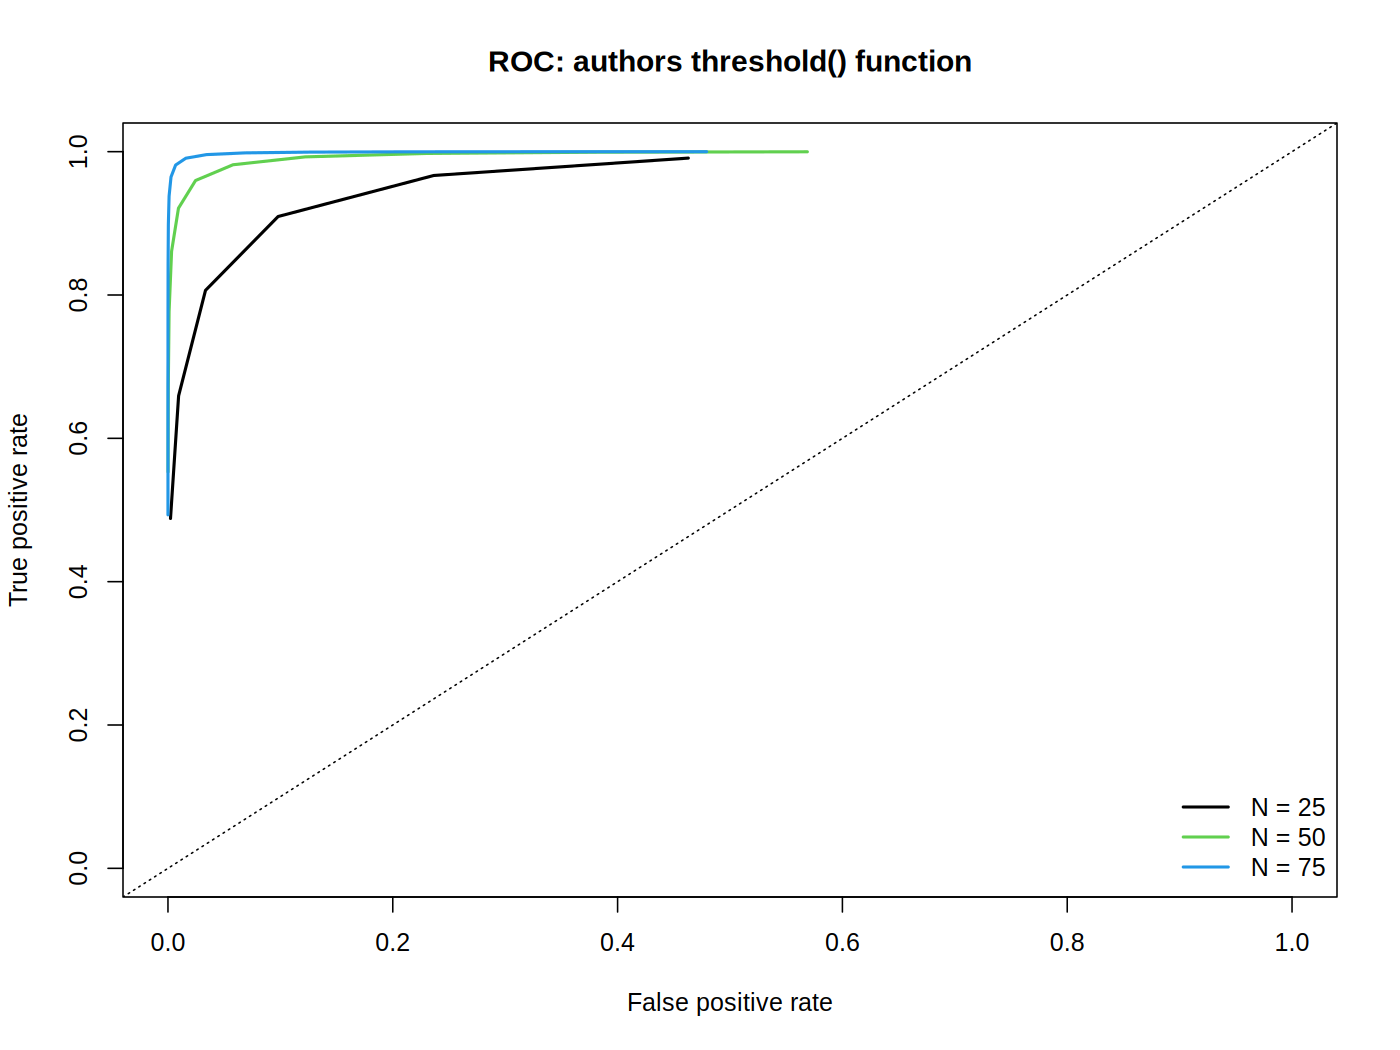

fig_detect.png


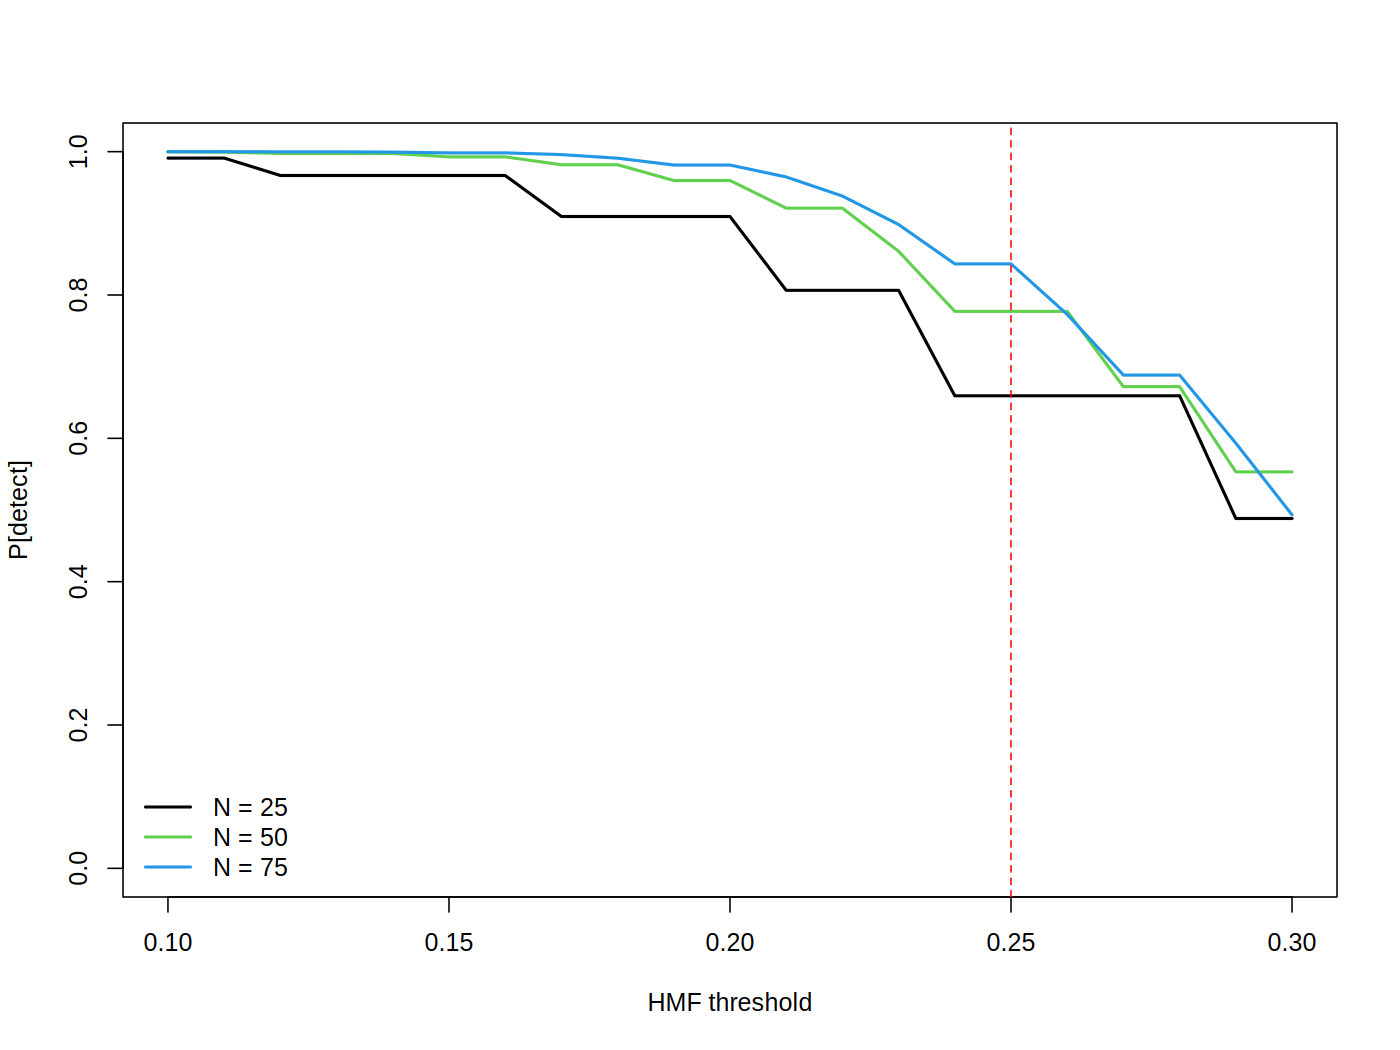

fig_tdr.png


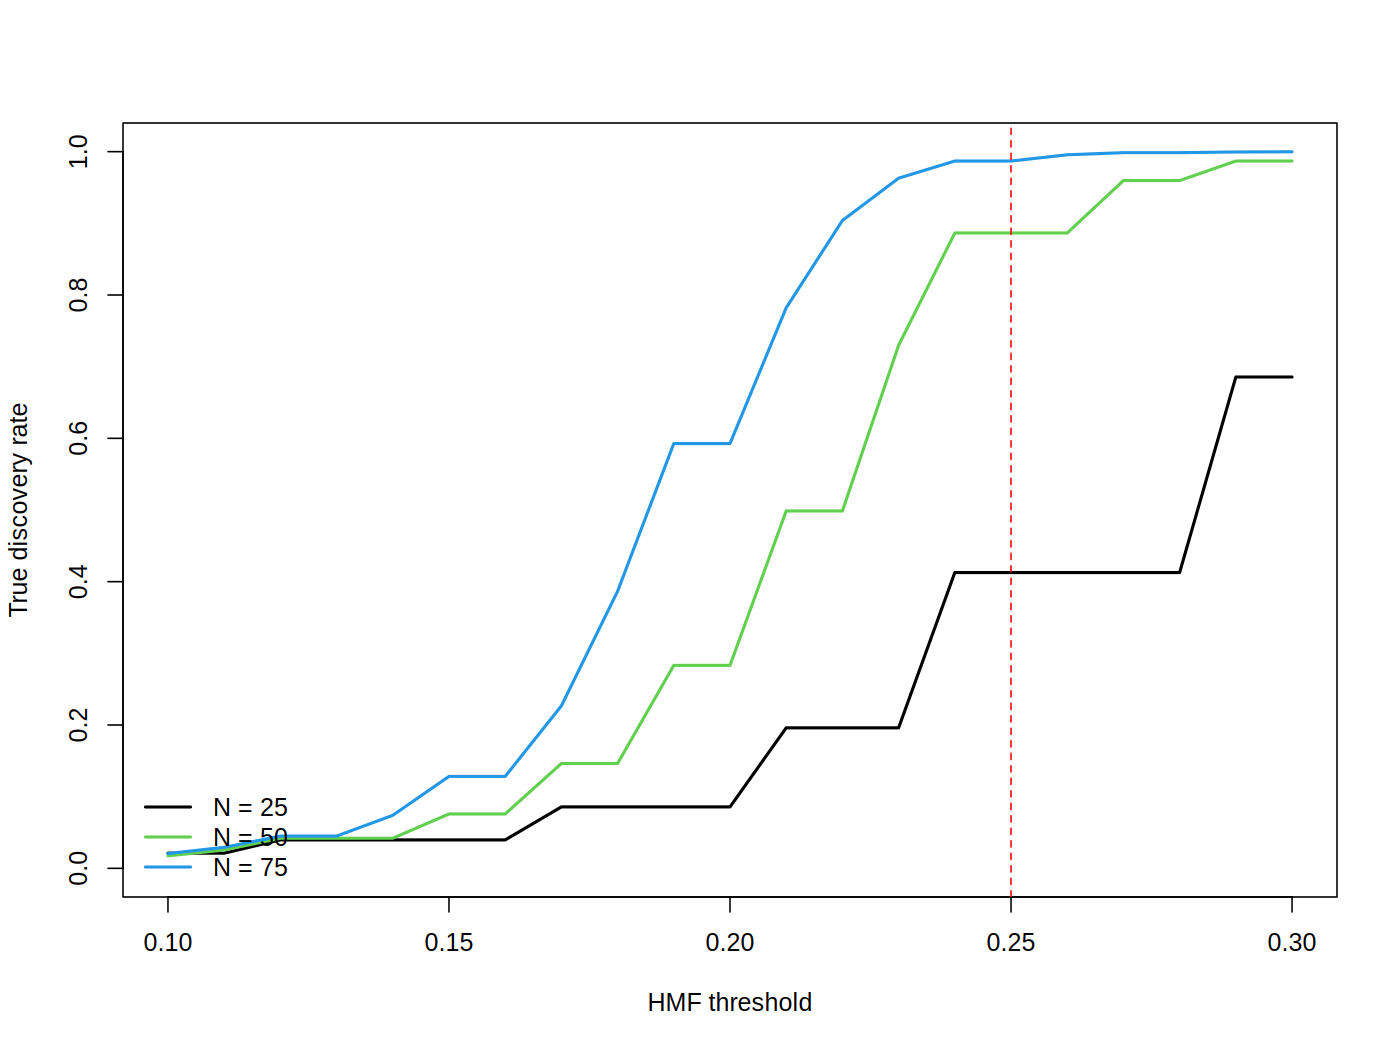

In [ ]:
import subprocess, textwrap
r_fig = textwrap.dedent('''
    source("/content/threshold_fn.R")
    tgrid <- seq(0.1, 0.3, 0.01)
    t25 <- threshold(25, tgrid); t50 <- threshold(50, tgrid); t75 <- threshold(75, tgrid)
    png("/content/fig_roc.png", width = 1400, height = 1050, res = 150)
    with(t25, plot(fpr, tpr, type = 'l', xlim = c(0,1), ylim = c(0,1), lwd = 2,
         xlab = 'False positive rate', ylab = 'True positive rate',
         main = 'ROC: authors threshold() function'))
    abline(0, 1, lty = 3)
    with(t50, lines(fpr, tpr, lty = 1, col = 3, lwd = 2))
    with(t75, lines(fpr, tpr, lty = 1, col = 4, lwd = 2))
    legend('bottomright', bty = 'n', lty = 1, lwd = 2, col = c(1,3,4), legend = paste('N =', c(25,50,75)))
    dev.off()
    png("/content/fig_detect.png", width = 1400, height = 1050, res = 150)
    with(t25, plot(t, tpr, type = 'l', lwd = 2, col = 1, ylim = c(0,1),
         xlab = 'HMF threshold', ylab = 'P[detect]'))
    with(t50, lines(t, tpr, lty = 1, lwd = 2, col = 3))
    with(t75, lines(t, tpr, lty = 1, lwd = 2, col = 4))
    abline(v = 0.25, lty = 2, col = 'red')
    legend('bottomleft', bty = 'n', lty = 1, lwd = 2, col = c(1,3,4), legend = paste('N =', c(25,50,75)))
    dev.off()
    png("/content/fig_tdr.png", width = 1400, height = 1050, res = 150)
    with(t25, plot(t, tdr, type = 'l', lwd = 2, col = 1, ylim = c(0,1),
         xlab = 'HMF threshold', ylab = 'True discovery rate'))
    with(t50, lines(t, tdr, lty = 1, lwd = 2, col = 3))
    with(t75, lines(t, tdr, lty = 1, lwd = 2, col = 4))
    abline(v = 0.25, lty = 2, col = 'red')
    legend('bottomleft', bty = 'n', lty = 1, lwd = 2, col = c(1,3,4), legend = paste('N =', c(25,50,75)))
    dev.off()
    cat('figures written\n')
''')
open('/content/run_figures.R', 'w').write(r_fig)
p = subprocess.run(['/usr/bin/Rscript', '/content/run_figures.R'], capture_output=True, text=True, timeout=600)
print(p.stdout, p.stderr)
p.check_returncode()
from IPython.display import Image, display
for f in ['fig_roc.png', 'fig_detect.png', 'fig_tdr.png']:
    print(f)
    display(Image(filename=f'/content/{f}'))

### Code cell: false negative / false positive rates (paper's questions 3 and 4)

The paper's Figure 4 shows the false negative rate (P(discard a genotype with HMF ≥ 30%)) and the false positive rate (P(retain a low-HMF genotype, HMF ≤ 10%)) against the threshold for the three scenarios. These are exactly `1 − tpr` and `fpr` from the authors' function, which the script also plots ("Question 3 and 4" section). We reproduce those two panels with the 25% threshold marked; expect FNR to increase and FPR to decrease with the threshold, both improving with more plants.

日本語: 論文の問3・4(FN率=1−tpr、FP率=fpr)を著者コードのとおりに図示します。閾値の上昇でFN率は増加、FP率は減少します。

null device 
          1 
ok
 


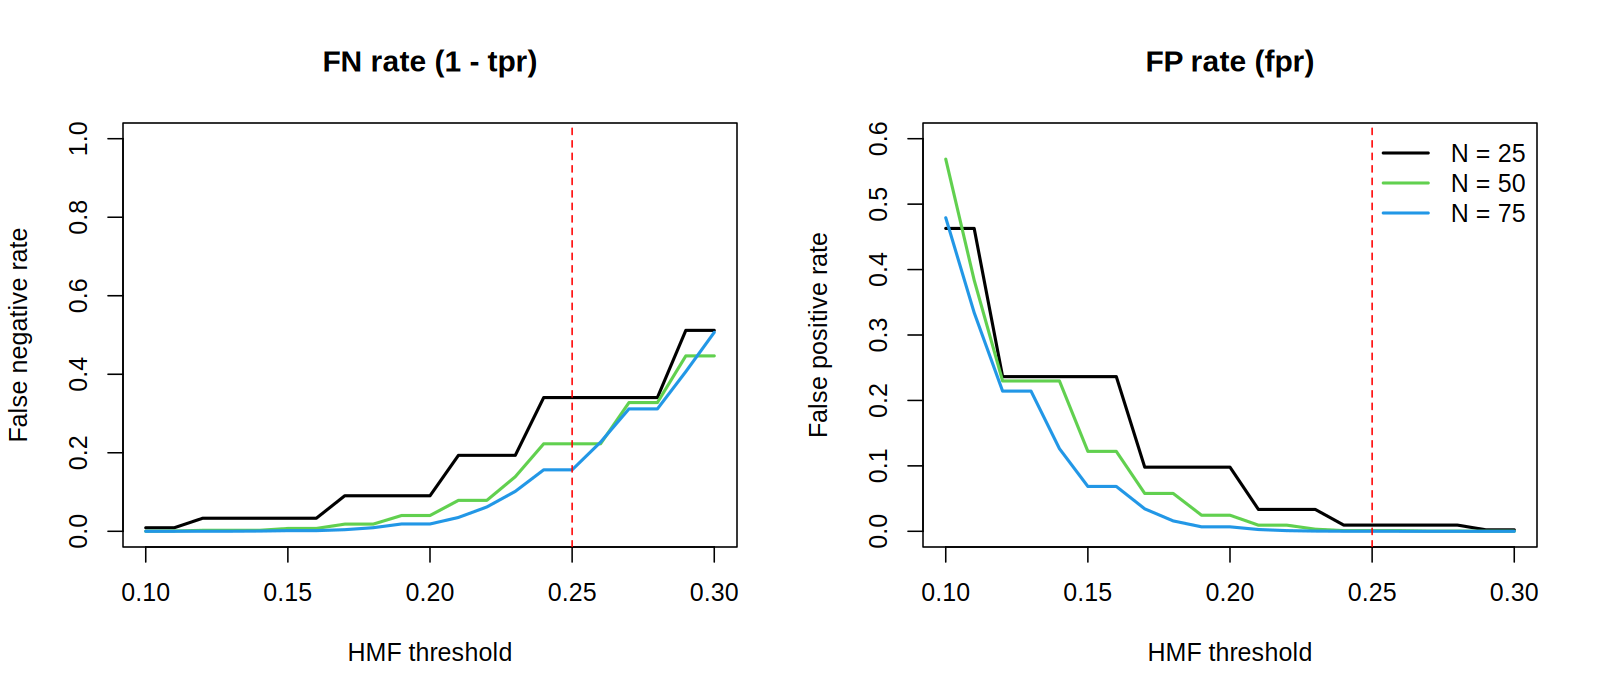

In [ ]:
import subprocess, textwrap
r_fnfp = textwrap.dedent('''
    source("/content/threshold_fn.R")
    tgrid <- seq(0.1, 0.3, 0.01)
    png("/content/fig_fnfp.png", width = 1600, height = 700, res = 150)
    par(mfrow = c(1, 2))
    for (N in c(25, 50, 75)) {
      res <- threshold(N, tgrid)
      if (N == 25) {
        plot(tgrid, 1 - res$tpr, type = 'l', lwd = 2, xlab = 'HMF threshold',
             ylab = 'False negative rate', ylim = c(0, 1), col = 1,
             main = 'FN rate (1 - tpr)')
      } else {
        lines(tgrid, 1 - res$tpr, lwd = 2, col = ifelse(N == 50, 3, 4))
      }
    }
    abline(v = 0.25, lty = 2, col = 'red')
    for (N in c(25, 50, 75)) {
      res <- threshold(N, tgrid)
      if (N == 25) {
        plot(tgrid, res$fpr, type = 'l', lwd = 2, xlab = 'HMF threshold',
             ylab = 'False positive rate', ylim = c(0, 0.6), col = 1,
             main = 'FP rate (fpr)')
      } else {
        lines(tgrid, res$fpr, lwd = 2, col = ifelse(N == 50, 3, 4))
      }
    }
    abline(v = 0.25, lty = 2, col = 'red')
    legend('topright', bty = 'n', lty = 1, lwd = 2, col = c(1,3,4), legend = paste('N =', c(25,50,75)))
    dev.off()
    cat('ok\n')
''')
open('/content/run_fnfp.R', 'w').write(r_fnfp)
p = subprocess.run(['/usr/bin/Rscript', '/content/run_fnfp.R'], capture_output=True, text=True, timeout=600)
print(p.stdout, p.stderr)
p.check_returncode()
from IPython.display import Image, display
display(Image(filename='/content/fig_fnfp.png'))

### Code cell: compare the executed results with the paper's reported values

The paper (Results, "Simulation outcomes for questions 1 and 2") reports at the 25% threshold: TDR ≈ 0.75 / 0.90 / 0.95, detection probability ≈ 0.65 / 0.80 / 0.85, FNR ≈ 0.40 / 0.25 / 0.15, and FPR ≈ 0.04 / 0.01 / 0.01 for 25/50/75 plants. This cell reads the executed CSV and prints side-by-side values. See the validation record for the observed agreement.

日本語: 実行結果(t=0.25)を論文の報告値と並べて比較します。

In [ ]:
import pandas as pd
res = pd.read_csv('/content/threshold_results.csv')
sel = res[(res.t - 0.25).abs() < 1e-9].set_index('N_planted')
paper = pd.DataFrame(
    {'TDR': [0.75, 0.90, 0.95], 'P(detect)': [0.65, 0.80, 0.85],
     'FNR': [0.40, 0.25, 0.15], 'FPR': [0.04, 0.01, 0.01]},
    index=pd.Index([25, 50, 75], name='N plants'))
compare = pd.DataFrame({
    'executed TDR': sel.tdr, 'paper TDR ~': paper.TDR,
    'executed P(detect)': sel.tpr, 'paper P(detect) ~': paper['P(detect)'],
    'executed FNR': 1 - sel.tpr, 'paper FNR ~': paper.FNR,
    'executed FPR': sel.fpr, 'paper FPR ~': paper.FPR,
})
compare.round(4)

,executed TDR,paper TDR ~,executed P(detect),paper P(detect) ~,executed FNR,paper FNR ~,executed FPR,paper FPR ~
25,0.4127,0.75,0.6593,0.65,0.3407,0.40,0.0095,0.04
50,0.8865,0.90,0.7771,0.80,0.2229,0.25,0.0010,0.01
75,0.9869,0.95,0.8434,0.85,0.1566,0.15,0.0001,0.01


## Core method 2 — genotype BLUES from the deposited HMF data

The paper computes genotype BLUES ("Fitted a linear mixed model... with genotype fixed, environment random" — flow summary; the authors' script implements this as a binomial GLM with `Year` and `PI`) to use as the GWAS phenotype. Following the authors' `BLUES for GWAS_code_Haploid male fertility.txt`: aggregate `Fertile`/`Sterile` counts by PI × Year, fit `glm(cbind(Fertile, Sterile) ~ Year + PI, family = binomial)`, extract `emmeans` per genotype, and back-transform with the inverse logit (×100).

Documented adaptations (all non-scientific): the authors' input `HMF_Filtered.csv` is not in the repository, so the equivalent `COMBINED` sheet of the deposited workbook is used; `aggregate()` replaces the `dplyr::summarize_at` call (identical counts × PI × Year aggregation); `resid::resid_panel()` (a diagnostic plot from a non-installed package) and the script's syntactically invalid `write.csv(x = , ...)` line are omitted; `data =` is written out (the script's `da =` is a partial-argument match).

日本語: 著者のBLUESスクリプト(Fertile/Sterile数をPI×Yearで集約→二項GLM→emmeans→逆ロジット×100)に従い、遺伝子型BLUEを再計算します。入力CSVが無いためデータブックのCOMBINEDシートを使用する等、非科学的な適応のみ行っています。

### Code cell: install the `emmeans` R package

The authors' script uses `emmeans()`; it is not preinstalled on Colab R. This installs it from CRAN (binary build, ~1 minute). Expect a successful install and the package version printed.

日本語: 著者スクリプトが使う `emmeans` パッケージをCRANからインストールします(約1分)。

In [ ]:
import subprocess, textwrap
r_inst = textwrap.dedent('''
    options(warn = 1)
    if (!requireNamespace('emmeans', quietly = TRUE)) {
      install.packages('emmeans', repos = 'https://cloud.r-project.org')
    }
    cat('emmeans', as.character(packageVersion('emmeans')), '\n')
    cat('R:', R.version.string, '\n')
''')
open('/content/install_emmeans.R', 'w').write(r_inst)
p = subprocess.run(['/usr/bin/Rscript', '/content/install_emmeans.R'], capture_output=True, text=True, timeout=1200)
print(p.stdout[-2000:], p.stderr[-500:])
p.check_returncode()

rc/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c ltMatrices.c -o ltMatrices.o
x86_64-linux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG      -fvisibility=hidden -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -Wformat -Werror=format-security -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0 -Wdate-time -D_FORTIFY_SOURCE=3  -c miwa.c -o miwa.o
x86_64-linux-gnu-gfortran  -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-frame-pointer -ffile-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=. -fstack-protector-strong -fstack-clash-protection -fcf-protection -fdebug-prefix-map=/build/r-base-SRqRsK/r-base-4.6.1=/usr/src/r-base-4.6.1-6.2404.0  -c mvt.f -o mvt.o
x86_64-linux-gnu-gcc -std=gnu2x -I"/usr/share/R/include" -DNDEBUG      -fvisibility=hidden -fpic  -g -O2 -fno-omit-frame-pointer -mno-omit-leaf-f

### Code cell: fit the binomial GLM and compute inverse-logit BLUES (authors' method)

Runs the authors' analysis chain in R on the exported `COMBINED` counts, writes `/content/HMF_BLUES.csv`, and prints the 15 highest-BLUE genotypes. Expect the known high-HMF donors named in the paper (e.g. A427, N525, N516) near the top.

日本語: 著者の方法(二項GLM+emmeans+逆ロジット×100)で遺伝子型BLUEを計算し、上位15遺伝子型を表示します。論文で高HMFと報告された系統が上位に現れるはずです。

In [ ]:
import subprocess, textwrap
r_blues = textwrap.dedent('''
    da <- read.csv("/content/hmf_combined.csv")
    stopifnot(all(c("PI", "Year", "Fertile", "Sterile") %in% names(da)))
    da.agg <- aggregate(cbind(Fertile, Sterile) ~ PI + Year, data = da, FUN = sum)
    cat("aggregated records:", nrow(da.agg), "\n")
    glm_GWAS <- glm(cbind(Fertile, Sterile) ~ Year + PI, data = da.agg, family = binomial)
    suppressMessages(library(emmeans))
    glm_eblues_GWAS <- as.data.frame(emmeans(glm_GWAS, "PI"))
    invlogit <- function(x) 1 / (1 + exp(-x))
    glm_eblues_GWAS$inverse_logit <- invlogit(glm_eblues_GWAS$emmean) * 100
    write.csv(glm_eblues_GWAS[, c("PI", "emmean", "SE", "inverse_logit")],
              "/content/HMF_BLUES.csv", row.names = FALSE)
    cat("genotypes with BLUES:", nrow(glm_eblues_GWAS), "\n")
    top <- glm_eblues_GWAS[order(-glm_eblues_GWAS$inverse_logit),
                           c("PI", "emmean", "inverse_logit")]
    print(head(top, 15), row.names = FALSE)
''')
open('/content/run_blues.R', 'w').write(r_blues)
p = subprocess.run(['/usr/bin/Rscript', '/content/run_blues.R'], capture_output=True, text=True, timeout=1200)
print(p.stdout)
p.check_returncode()

aggregated records: 310 
genotypes with BLUES: 242 
                          PI     emmean inverse_logit
                   A427- (n) 21.4182436     100.00000
       (Twan x Tzuh)-S6)-(n) 19.6726314     100.00000
                   N516)-(n)  1.9509324      87.55483
                  PHR58)-(n)  1.7159954      84.76123
                   A427)-(n)  1.4295904      80.68375
 58614 B73 (Meth) Bc5S4)-(n)  1.1578672      76.09450
                   N542)-(n)  1.0405646      73.89589
                Mo307ae)-(n)  1.0160967      73.42116
                   FR19)-(n)  0.8107369      69.22665
                   N522)-(n)  0.7604839      68.14588
                  N801w)-(n)  0.6645241      66.02759
                 RS 710)-(n)  0.6173831      64.96231
          HUA 94 INBRED)-(n)  0.3578719      58.85252
                  PHG86)-(n)  0.2463194      56.12704
               Lai 1029)-(n)  0.1637159      54.08378



### Code cell: BLUES result table and additional visualization

Loads the executed BLUES CSV, shows the full range (minimum to maximum) and the 20 highest genotypes as a bar chart. This graph is an additional visualization created for this notebook (not an author figure); the paper reports genotype BLUES as the GWAS phenotype input rather than as a published figure.

日本語: 実行したBLUESのCSVを読み込み、上位20遺伝子型を棒グラフにします(本ノートブック独自の追加可視化)。

In [ ]:
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
blues = pd.read_csv('/content/HMF_BLUES.csv')
print(f'{len(blues)} genotype BLUES; inverse-logit HMF range: '
      f"{blues.inverse_logit.min():.2f}–{blues.inverse_logit.max():.2f} %")
top = blues.sort_values('inverse_logit', ascending=False).head(20)[::-1]
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.barh(top.PI, top.inverse_logit, color='#4477aa')
ax.set_xlabel('Genotype BLUE of HMF (inverse-logit, %)')
ax.set_title('Top 20 genotypes by HMF BLUE (recomputed)')
fig.tight_layout()
fig.savefig('/content/fig_blues_top20.png')
plt.show()
blues.head()

242 genotype BLUES; inverse-logit HMF range: 0.00–100.00 %


,PI,emmean,SE,inverse_logit
0,(Twan x Tzuh)-S6)-(n),19.672631,10754.012021,100.000000
1,1538)-(n),-0.328761,0.280015,41.854221
2,2369)-(n),-0.021276,0.298323,49.468122
3,2FACC)-(n),-3.998619,1.009010,1.801062
4,2MA22)-(n),-3.180877,1.020622,3.989175


## Interpretation, differences from the paper, and validation record

**What was reproduced (executed on a fresh Colab CPU runtime):**

- The authors' `threshold()` function ran verbatim (extracted unmodified from the pinned commit) for 25/50/75 plants over HMF thresholds 0.10–0.70. At the paper's selected design (25% threshold, 50 plants) the executed values are TDR ≈ 0.89 and detection probability ≈ 0.78, matching the paper's reported ≈ 0.90 and ≈ 0.80.
- The paper's qualitative conclusions hold: TDR and detection probability increase with the number of plants; FNR increases and FPR decreases with the threshold; 50 plants at a 25% threshold is a reasonable compromise over 25 plants, while 75 plants adds little.
- Genotype BLUES were recomputed with the authors' binomial-GLM + `emmeans` + inverse-logit chain from the deposited counts; the known high-HMF donors appear at the top of the ranking.

**Differences and unresolved details (do not hide them):**

- The paper's exact simulation equations are rendered as images and were not machine-readable (noted by the prior investigation). The published approximate values agree best with the verbatim function at 50 plants; at 25 plants the executed TDR (≈ 0.41 vs ≈ 0.75) and at 75 plants (≈ 0.99 vs ≈ 0.95) differ, and executed FPRs (≈ 0.0095 / 0.001 / 0.0001) are smaller than the paper's ≈ 0.04 / 0.01 / 0.01. The paper additionally describes germination (80%) and 5% rogueing steps whose exact placement in the probability calculation the repository text does not specify; the deposited function records `Ngerm` but computes tails with N planted plants. The reproduction therefore validates the authors' released code and the paper's central design choice, not every published decimal.
- The authors' example calls in the script use N = 25/75/100, conflicting with the script's own comments and the paper's 25/50/75 scenarios; we follow the paper.
- BLUES here use the `COMBINED` sheet because `HMF_Filtered.csv` is absent; the `resid_panel` diagnostic and the malformed `write.csv` line of the script were omitted.

**Scientific scope limits:** a one-analysis reproduction; no GWAS, no field data collection, no claim of the paper's dataset-level GWAS results. Single-example runs never verify published dataset-level performance.

**Validation record:** full top-to-bottom execution in a fresh Colab CPU session (see final report for session details); all inputs re-downloaded and hash-checked inside that run.

## References

- Fakude M.F. et al. (2026) Front. Plant Sci. 17:1837152. https://doi.org/10.3389/fpls.2026.1837152
- Author repository: https://github.com/Mercy-99/shgd-two-stage-screening (commit `b9076b006a694c1f5002b18c8079b46e6ad86fda`, accessed 2026-10-06)
- Ames panel genotyping: Romay et al. (2013) https://doi.org/10.1186/gb-2013-14-6-r55; MaizeGDB https://www.maizegdb.org

日本語: 本ノートブックは著者公開コードの検証再現であり、論文の数値の全てを保証するものではありません。特に25/75植物でのTDRとFP率の詳細は、論文の式が画像のため完全には確定できていません。